In [1]:
from datasets import load_dataset
from datasets import Dataset
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print as pprint
import numpy as np
import pandas as pd
import random
import re
# from parlai.utils.safety import OffensiveLanguageClassifier
# from rouge_score import rouge_scorer
# import evaluate

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
ds = load_dataset("google/boolq", cache_dir='/data/takis/datasets/hf_hub')['train']

In [3]:
ds

Dataset({
    features: ['question', 'answer', 'passage'],
    num_rows: 9427
})

In [4]:
ds[0]

{'question': 'do iran and afghanistan speak the same language',
 'answer': True,
 'passage': 'Persian (/ˈpɜːrʒən, -ʃən/), also known by its endonym Farsi (فارسی fārsi (fɒːɾˈsiː) ( listen)), is one of the Western Iranian languages within the Indo-Iranian branch of the Indo-European language family. It is primarily spoken in Iran, Afghanistan (officially known as Dari since 1958), and Tajikistan (officially known as Tajiki since the Soviet era), and some other regions which historically were Persianate societies and considered part of Greater Iran. It is written in the Persian alphabet, a modified variant of the Arabic script, which itself evolved from the Aramaic alphabet.'}

In [5]:
def sort_two_arrays(arr1, arr2):
    """Sorts two arrays based on the order of the first array.

    Args:
    arr1: The array to sort by.
    arr2: The array to sort along with the first array.

    Returns:
    A tuple containing the sorted arr1 and arr2.
    """

    zipped_pairs = zip(arr1, arr2)
    sorted_pairs = sorted(zipped_pairs)

    sorted_arr1 = [x for x, _ in sorted_pairs]
    sorted_arr2 = [y for _, y in sorted_pairs]

    return sorted_arr1, sorted_arr2

In [6]:
prompts = []

for i, row in tqdm(enumerate(ds), total=len(ds)):
    prompts.append('passage: %s, question: %s, answer: %s' %(row['passage'], row['question'], row['answer']))
prompts = np.array(prompts)

keep_idx = random.sample(list(range(len(prompts))), 600)
prompts = prompts[keep_idx]

len(prompts)

  0%|          | 0/9427 [00:00<?, ?it/s]

100%|██████████| 9427/9427 [00:00<00:00, 72706.67it/s]


600

# Model

In [7]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '7'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [8]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)
model = model.eval()

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  6.97it/s]


# Hidden states

In [9]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    # layer.self_attn.register_forward_hook(get_activation(i))
    hooks.append(layer.register_forward_hook(get_activation(i)))

In [10]:
hidden_states = []
activations = {}

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 1077: 100%|██████████| 600/600 [00:30<00:00, 19.80it/s]


In [11]:
target_layers = [i for i in range(len(model.model.layers))]
all_prompts_prototypes = hidden_states

# Cosine similarity

In [12]:
# for target_layer in target_layers:

#     dis = np.zeros((len(prompts), len(prompts)))
#     cs = np.zeros((len(prompts), len(prompts)))

#     cs_func = nn.CosineSimilarity(dim=-1)

#     for i in range(len(prompts)):
#         for j in range(len(prompts)):
#             dis[i, j] = torch.linalg.norm(all_prompts_prototypes[i][target_layer] - all_prompts_prototypes[j][target_layer])
#             cs[i, j] = cs_func(all_prompts_prototypes[i][target_layer], all_prompts_prototypes[j][target_layer])


#     fig, ax = plt.subplots(figsize=(3, 3))
#     plt.imshow(cs, cmap='Reds')
#     plt.title(str(target_layer))
#     plt.show()

# Different prompts t-sne

In [12]:
# ic_prompts = ["Write a short factual passage about a real-world topic, followed by a true-or-false question directly based on a detail in the passage. Provide the answer as 'true' or 'false'.",
#            "Generate a passage that implies something not explicitly stated. Then create a true-or-false question that requires inference from the passage, and provide the answer.",
#            "Invent a passage about a historical or scientific topic, then write a question that contains a subtle factual error. Answer with 'true' or 'false' accordingly.",
#            "Create a short informative passage, then generate a question that paraphrases part of it but introduces a slight inaccuracy. Provide the true/false answer.",
#            "Write a passage involving contrasting facts or events. Then ask a true-or-false question using negation (e.g., 'did not', 'never'), and answer it.",
#            "Generate a passage involving cause-and-effect or events in time. Then write a true-or-false question that tests understanding of that structure, and give the answer.",
#            "Write a passage that sounds plausible. Then ask a question that seems likely but is actually false given the passage. Provide the correct answer.",
#            "Produce a passage that could be misinterpreted, then pose a true-or-false question that tests precise understanding. Provide the correct answer.",
#            "Create a passage that blends general world knowledge with specific details. Then write a true-or-false question grounded only in the passage, and answer it.",
#            "Write a passage on a narrow topic. Then ask a question that seems related but is not supported by the passage. Provide 'false' as the answer."]

In [13]:
# hidden_states = []
# activations = {}

# pbar = tqdm(enumerate(prompts[:10]), total=len(prompts[:10]))
# for i, p in pbar:

#     for icp in ic_prompts:

#         pbar.set_description('cur prompt length (chars): %d' %(len(p)))
        
#         with torch.no_grad():
#             inputs = tokenizer(p + '\n' + icp, return_tensors="pt").input_ids
#             outputs = model.forward(inputs.to(device))
            
#         for k in activations.keys():
#             activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
#             activations[k] =  torch.mean(activations[k], dim=-2)


#         hidden_states.append(copy.deepcopy(activations))
#         activations = {}

cur prompt length (chars): 495: 100%|██████████| 10/10 [01:46<00:00, 10.64s/it]


In [21]:
# target_layer = 24

# cur_prototypes = []
# for i in range(len(hidden_states)):
#     cur_prototypes.append(hidden_states[i][target_layer])
# cur_prototypes = torch.stack(cur_prototypes, dim=0).squeeze()

In [22]:
# cur_prototypes.shape

torch.Size([100, 4096])

In [23]:
# cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=8, random_state=0).fit_transform(cur_prototypes.detach().to(float).cpu().numpy())

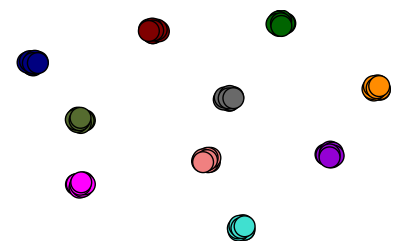

In [29]:
# from matplotlib import rcParams


# rcParams['font.family'] = 'serif'
# rcParams['text.usetex'] = True

# rcParams['axes.grid'] = False
# rcParams['grid.linestyle'] = '--'
# rcParams['grid.alpha'] = 0.9

# rcParams['axes.facecolor'] = 'white'
# # rcParams['axes.facecolor'] = '#f8f9fa'
# # rcParams['axes.linewidth'] = 2
# # rcParams['axes.axisbelow'] = True
# rcParams['axes.labelsize'] = 35
# rcParams['axes.titlesize'] = 30

# rcParams['axes.spines.top'] = False
# rcParams['axes.spines.right'] = False
# rcParams['axes.spines.bottom'] = False
# rcParams['axes.spines.left'] = False

# rcParams['lines.linewidth'] = 4
# rcParams['lines.markersize'] = 15

# rcParams['legend.fontsize'] = 25
# rcParams['xtick.labelsize'] = 25
# rcParams['ytick.labelsize'] = 25
# rcParams['figure.figsize'] = (5, 3)

# plt.scatter(cur_prototypes_emb[:, 0], cur_prototypes_emb[:, 1], c=10*['maroon'] + \
#                                                                   10*['darkgreen'] + \
#                                                                   10*['navy'] + \
#                                                                   10*['darkorange'] + \
#                                                                   10*['lightcoral'] + \
#                                                                   10*['dimgrey'] + \
#                                                                   10*['darkolivegreen'] + \
#                                                                   10*['turquoise'] + \
#                                                                   10*['darkviolet'] + \
#                                                                   10*['magenta'], edgecolor='black')
# plt.xticks([])
# plt.yticks([])
# plt.show()

# Behavior steering

In [26]:
for hook in hooks:
    hook.remove()

In [27]:
# target_prompt = 0
# strength = 1
# noise = 0
target_layer = 16


def change_behavior(target_layer):
    def hook(model, input, output):
        if (abs(strength) > 1e-5):
            output = (output[0] + strength*(all_prompts_prototypes[target_prompt][target_layer] + noise).to(device), *output[1:])
        return output
    return hook

def add_in_context_vector(target_layer):
    def hook(model, input, output):
        first_output = output[0]
        if (first_output.shape[-2] > 1 and abs(strength) > 1e-5):
            first_output[..., 1, :] = strength*all_prompts_prototypes[target_prompt][target_layer]
            output = (first_output, *output[1:])
        return output
    return hook


def add_noise(target_layer):
    def hook(model, input, output):
        first_output = output[0]
        # if (abs(strength) > 1e-5 and output[0].shape[-2] > 1):
        #     output = (output[0] + strength*noise.to(device), *output[1:])
        if (abs(strength) > 1e-5):
            output = (output[0] + strength*noise.to(device), *output[1:])
        return output
    return hook




hooks = []
for i, layer in enumerate(model.model.layers):
    if (i == target_layer):
        hooks.append(layer.self_attn.register_forward_hook(add_noise(i)))
        # hooks.append(layer.register_forward_hook(add_in_context_vector(i)))

In [23]:
target_prompt = 4

# prompt = 'Generate a similar sample in the format `passage: <PASSAGE>, question: <QUESTION>, answer: <ANSWER>`\n'
prompt = '''\n Now generate 3 different passages, questions, and answers similar to the example above. Please make sure each question you generate has a boolean answer that can be answered by the passage. Make sure each passage and question is different and sufficiently rephrased. Please make sure you generate passages, questions and both true and false answers.'''

# prompt = 'Generate a similar sample:'''

In [24]:
pprint (prompts[target_prompt])

passage: Casting for series one began in early 2009 in Brisbane, Melbourne and Sydney. All cast members had to be 
skilled in drama and dancing and had to cope with Australia's best choreographers. Filming began on 13 July 2009 
and wrapped up in early November. The series premiere was originally planned for a mid-2010 premiere on ABC3, 
however, like Dead Gorgeous, the premiere was pushed to ABC1 on 31 May 2010 and ABC3 on 6 June 2010. The first 
series premiered on Germany's ZDF on 26 September 2010., question: are the dancers on dance academy real dancers, 
answer: True

In [28]:
strength = 0
noise = 0 #torch.zeros(all_prompts_prototypes[target_prompt][target_layer].shape)

aug_prompt = prompts[target_prompt] + '\n' + prompt


responses = []


for _ in tqdm(range(2)):

    torch.manual_seed(0)

    with torch.no_grad():
        inputs = tokenizer(aug_prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=500, do_sample=True, top_k=50, top_p=0.95, temperature=0.6, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
    responses.append(output_text := tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0])

    activations = {}
    
    print ('-------------------------------------------------')
    print (strength)
    pprint ('%s' %(output_text))
    




for denom in [10, 15, 20, 40, 100]:
    for _ in tqdm(range(10)):

        strength = 1


        torch.manual_seed(np.random.randint(low=0, high=1000000))
        noise = torch.randn(all_prompts_prototypes[target_prompt][target_layer].shape).to(torch.bfloat16)/denom

        print (noise)

        torch.manual_seed(0)

        with torch.no_grad():
            # inputs = tokenizer(prompt, return_tensors="pt").input_ids
            inputs = tokenizer(aug_prompt, return_tensors="pt").input_ids
            outputs = model.generate(inputs.to(device), max_new_tokens=500, do_sample=True, top_k=20, top_p=0.95, temperature=0.2, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
        responses.append(output_text := tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0])
        # output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        print ('-------------------------------------------------')
        print (denom)
        pprint ('%s' %(output_text))
            
        

  0%|          | 0/2 [00:00<?, ?it/s]

-------------------------------------------------
0


Here are the 3 generated passages, questions, and answers:


passage: The series was produced by Jonathan M. Shiff, and it was first broadcast on ABC3 in Australia. It 
premiered in the United States on 3 September 2010 on Disney Channel. The series follows the lives of a group of 
young dancers training at the National Academy of Ballet. The series was well received by critics and audiences 
alike, and it was renewed for a second season. The series finale aired on 21 July 2013. The series has been 
broadcast in over 100 countries worldwide. The main characters include Ollie Lloyd, Abigail Armstrong, Tara Webb, 
and Benjamin Carter. The series also features a number of guest stars throughout its run, including a number of 
well-known ballet dancers. The series has been praised for its portrayal of the ballet world and its characters' 
struggles with fame, love, and identity. The series has also been praised for its choreography and its portrayal of
the physical and mental demands of professional ballet.

question: was the series renewed for a second season, answer: True

passage: The series was produced by Jonathan M. Shiff, and it was first broadcast on ABC3 in Australia. It 
premiered in the United States on 3 September 2010 on Disney Channel. The series follows the lives of a group of 
young dancers training at the National Academy of Ballet. The series was well received by critics and audiences 
alike, but it was not renewed for a second season. The series finale aired on 21 July 2013. The series has been 
broadcast in over 100 countries worldwide. The main characters include Ollie Lloyd, Abigail Armstrong, Tara Webb, 
and Benjamin Carter. The series also features a number of guest stars throughout its run, including a number of 
well-known ballet dancers. The series has been praised for its portrayal of the ballet world and its characters' 
struggles with fame, love, and identity. The series has also been praised for its choreography and its portrayal of
the physical and mental demands of professional ballet.

question: was the series renewed for a second season, answer: False

passage: The series was produced by Jonathan M. Shiff, and it was first broadcast on ABC3 in Australia. It 
premiered in the United States on 3 September 2010 on Disney Channel. The series follows the lives of a group of 
young dancers training at the National Academy of Ballet. The series was well received

 50%|█████     | 1/2 [00:09<00:09,  9.96s/it]

-------------------------------------------------
0


...

Passage 1:
The series premiered on 13 July 2009 in Australia and was broadcast on ABC3. The series was created by Jonathan M. 
Shiff and was produced by Jonathan M. Shiff Productions. The series was filmed in Brisbane, Melbourne and Sydney. 
The series was broadcast on ABC1 in 2010. The series was also broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was
broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The 
series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in
2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was
broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The 
series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in
2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was
broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The 
series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in
2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 201

 90%|█████████ | 9/10 [01:28<00:09,  9.89s/it]

tensor([[ 0.0015,  0.0083, -0.0143,  ..., -0.0090, -0.0077,  0.0022]],
       dtype=torch.bfloat16)
-------------------------------------------------
100


Passage 1:
The series premiered on 13 July 2009 in Australia and was broadcast on ABC3. The series was created by Jonathan M. 
Shiff and was produced by Jonathan M. Shiff Productions. The series was filmed in Brisbane, Melbourne and Sydney. 
The series was broadcast on ABC1 in 2010. The series was also broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was
broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The 
series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in
2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was
broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The 
series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in
2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was
broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The 
series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in
2010. The series was broadcast on ABC3 in 2010. The series was broadcast on ABC3 in 2010. The series was broadcast 
on ABC3 in 2010. The series was broadcast on ABC3 in 201

100%|██████████| 10/10 [01:38<00:00,  9.89s/it]


In [231]:
for i in range(len(responses)):
    responses[i] = re.sub(r'\s+', ' ', responses[i].strip())

In [232]:
def split_boolq_sample(sample):

    sample = re.sub(r'(?i)\bp\s*\d*\s*:', 'Passage:', sample)
    sample = re.sub(r'(?i)\bq\s*\d*\s*:', 'Question:', sample)
    sample = re.sub(r'(?i)\ba\s*\d*\s*:', 'Answer:', sample)

    splits = re.split(r'(?i)\bpassage\s*\d*\s*:', sample)

    for i in range(len(splits)):
        splits[i] = re.split(r'(?i)\bquestion\s*\d*\s*:', splits[i])[:2]
    for i in range(len(splits)):
        if (len(splits[i]) > 1):
            splits[i][1] = re.split(r'(?i)\banswer\s*\d*\s*:', splits[i][1])[:2]


    passages = []
    questions = []
    answers = []

    for s in splits:
        if (len(s) != 2 or len(s[1]) != 2):
            continue 

        passages.append(s[0].strip())
        questions.append(s[1][0].strip())


        answer = s[1][1].strip()
        if ('True' in answer or 'true' in answer or 'Yes' in answer or 'yes' in answer):
            answers.append(True)
        else:
            answers.append(False)
    

    return passages, questions, answers
        

In [233]:

for i in range(len(responses)):
    p, q, a = split_boolq_sample(responses[i])
    print (i, len(p))

# dict_dataset = {'passage': p, 'question': q, 'answer': a}

0 4
1 0
2 0
3 4
4 4
5 4
6 0
7 4
8 4
9 4
10 4
11 3
12 3
13 4
14 3
15 3
16 3
17 3
18 5
19 3
20 3
21 2
22 1
23 4
24 0
25 2
26 2
27 3
28 2
29 2
30 2
31 5
32 1
33 2
34 3
35 2
36 0
37 6
38 1
39 4
40 2


In [248]:
split_boolq_sample(responses[37])

(['The city of Los Angeles is located in the state of California. The city is known for its beaches, sunshine, and mild climate. The city is also known for its film and television industry. The city is home to the famous Hollywood sign.',
  'The city of New York is located in the state of New York. The city is known for its beaches, sunshine, and mild climate. The city is also known for its film and television industry. The city is home to the famous Hollywood sign.',
  'The city of New York is located in the state of California. The city is known for its beaches, sunshine, and mild climate. The city is also known for its film and television industry. The city is home to the famous Hollywood sign.',
  'The city of Chicago is located in the state of Illinois. The city is known for its beaches, sunshine, and mild climate. The city is also known for its film and television industry. The city is home to the famous Hollywood sign.',
  'The city of Chicago is located in the state of Californ

In [ ]:
new_ds = Dataset.from_dict(dict_dataset)
type(new_ds)

datasets.arrow_dataset.Dataset

In [ ]:
new_ds[1]

{'passage': 'The TV show "Who Wants to Be a Millionaire" has been on the air for over two decades. During that time, the show has featured many contestants who have gone on to win the top prize. One such contestant was John Carpenter, who won the million-dollar prize in 1999. Carpenter\'s win was notable for several reasons. Firstly, he was the first contestant to win the top prize without using any lifelines. Secondly, he was the first contestant to answer the final question without using the "50/50" lifeline. Lastly, he was the first contestant to call his father during the show\'s "phone a friend" lifeline to tell him that he was going to win the game. Carpenter\'s win made headlines and earned him national recognition.',
 'question': 'was John Carpenter the first contestant to win the top prize,',
 'answer': True}